# 05 - xAI Analysis: vollstaendige SHAP-Suite (basiert auf NB03)

Konsumiert angereicherte `shap_{model}_{plant}.pkl` (NB03): `shap_values`, `X`, `feature_names`, `base_value`, `timestamps`.

**Plots:** Bar | Beeswarm | Dependence | Waterfall | Force | Modellvergleich (MAE/RMSE/Pinball) | Pinball-Linien | SHAP-Heatmap (Stunde x Monat) | Forecast vs Actual + Baender.

In [1]:
from __future__ import annotations
from pathlib import Path
import sys, pickle, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import shap

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SHAP_DIR    = PROJECT_ROOT / "results" / "shap_explanations"
FORECAST_DIR= PROJECT_ROOT / "results" / "forecasts"
TABLES_DIR  = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
for d in [TABLES_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PLANTS = ["Schonungen", "Schwanfeld", "Trabelsdorf", "Obbach"]
MODELS = {"xgb": "XGBoost", "qgb": "QGB", "qrf": "QRF"}
PLOT_PLANT = "Schonungen"   # Referenz-Standort fuer lokale Plots
print("Setup OK")

Setup OK


## 1. SHAP-pkls laden (angereichert: shap, X, base, timestamps)

In [2]:
shap_data = {}
for plant in PLANTS:
    for mdl in MODELS:
        fp = SHAP_DIR / f"shap_{mdl}_{plant.lower()}.pkl"
        if fp.exists():
            with open(fp, "rb") as f:
                shap_data[(plant, mdl)] = pickle.load(f)
FEATURES = shap_data[(PLANTS[0], "xgb")]["feature_names"]
sample = shap_data[(PLANTS[0], "xgb")]
print(f"Loaded {len(shap_data)} files | {len(FEATURES)} features")
print("Keys per file:", list(sample.keys()))
print("Shapes:", "shap", sample["shap_values"].shape, "| X", np.asarray(sample["X"]).shape,
      "| base", round(float(sample["base_value"]), 3))

Loaded 12 files | 25 features
Keys per file: ['shap_values', 'X', 'feature_names', 'base_value', 'timestamps']
Shapes: shap (5000, 25) | X (5000, 25) | base 0.342


## 2. Bar Plot: globale Feature-Importance (mean|SHAP|) je Modell

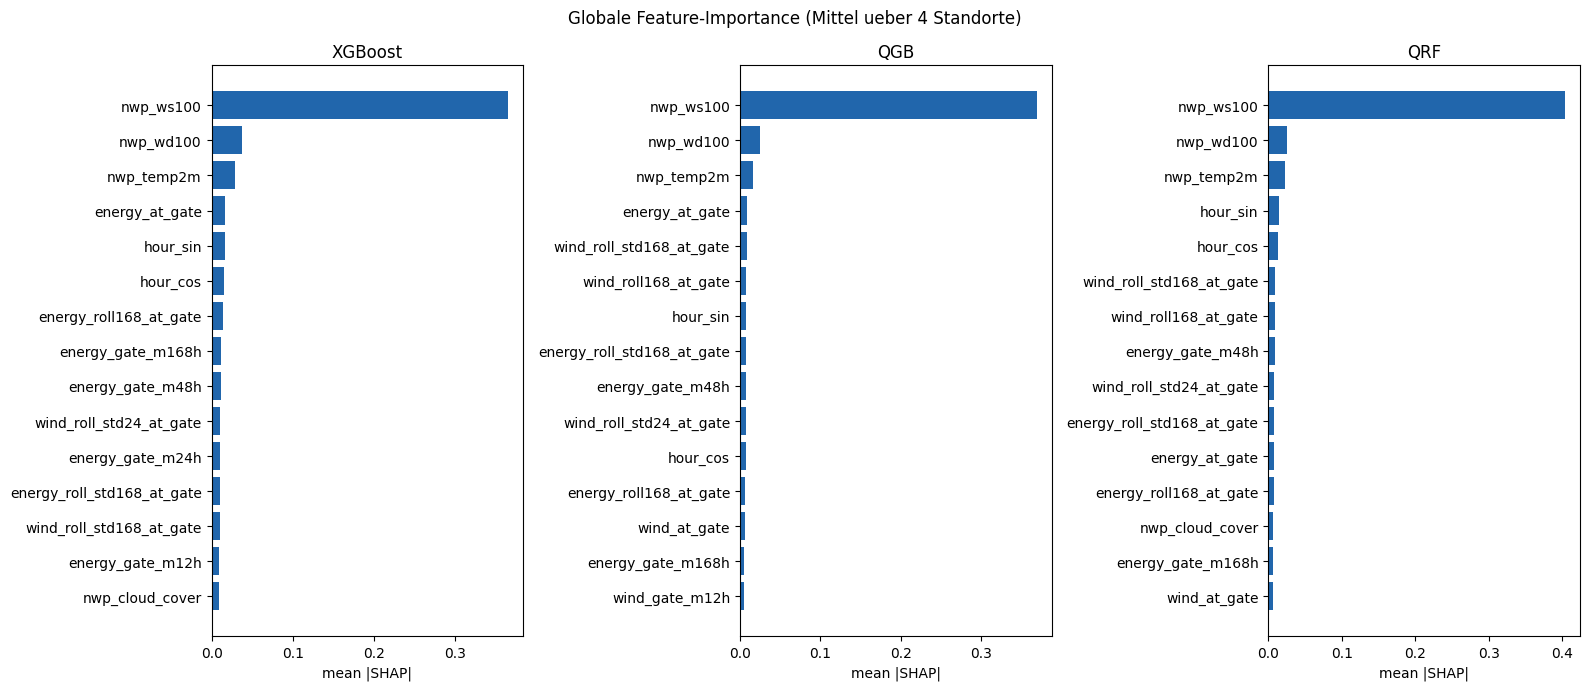

In [3]:
rows = []
for (plant, mdl), d in shap_data.items():
    imp = np.abs(d["shap_values"]).mean(axis=0)
    for f, v in zip(FEATURES, imp):
        rows.append({"plant": plant, "model": MODELS[mdl], "feature": f, "importance": float(v)})
imp_df = pd.DataFrame(rows)
imp_df.to_csv(TABLES_DIR / "shap_feature_importance.csv", index=False)
glob = imp_df.groupby(["model", "feature"])["importance"].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 7))
for ax, m in zip(axes, ["XGBoost", "QGB", "QRF"]):
    top = glob[glob["model"] == m].nlargest(15, "importance").sort_values("importance")
    ax.barh(top["feature"], top["importance"], color="#2166ac")
    ax.set_title(m); ax.set_xlabel("mean |SHAP|")
plt.suptitle("Globale Feature-Importance (Mittel ueber 4 Standorte)"); plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_bar_importance.png", dpi=150); plt.show()

## 3. Beeswarm / Summary Plot (je Modell, Schonungen)

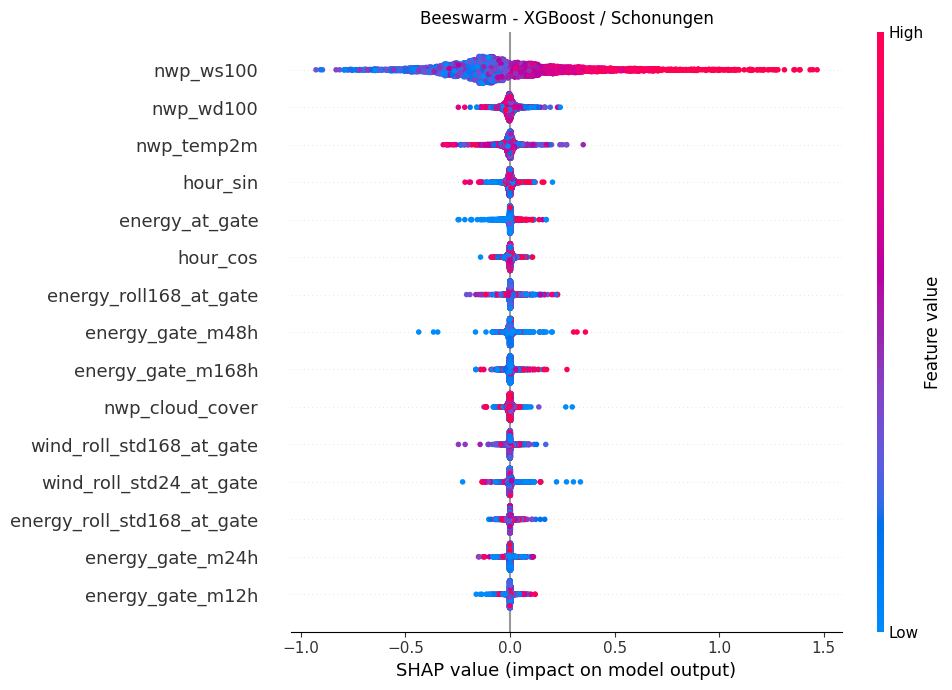

  beeswarm xgb OK


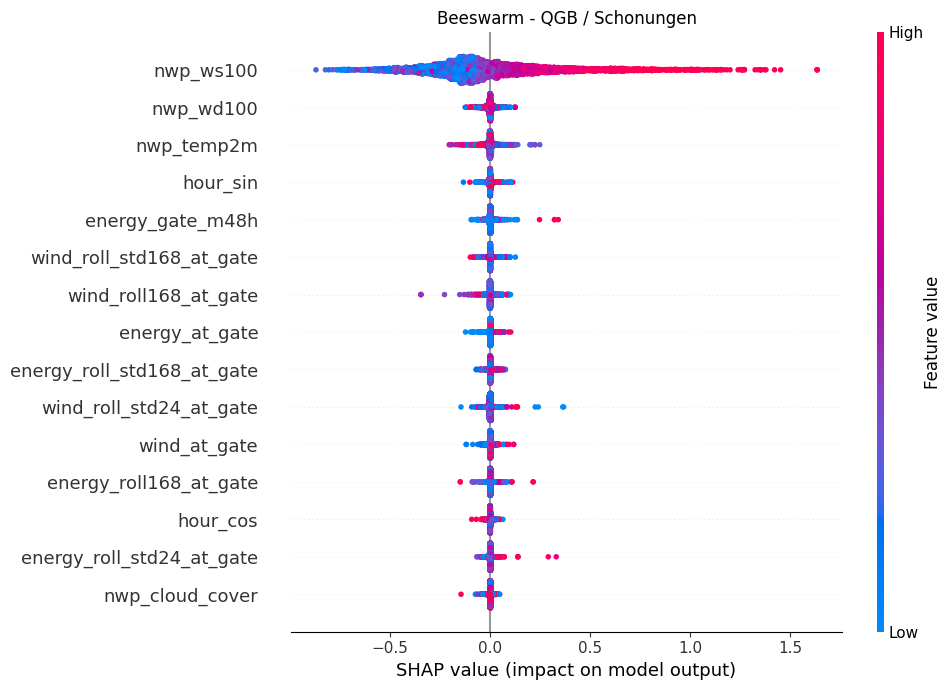

  beeswarm qgb OK


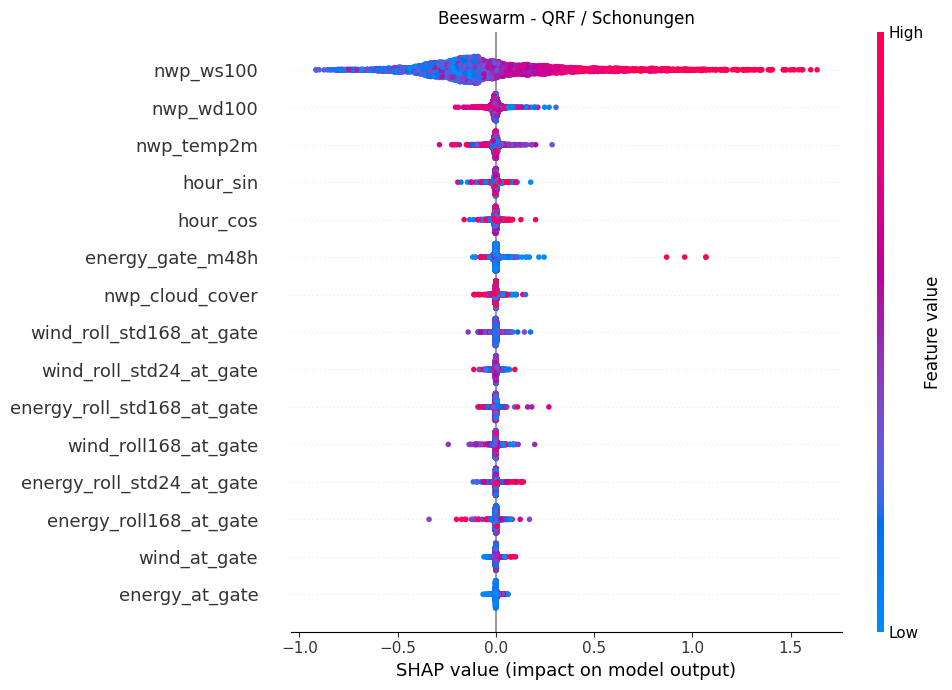

  beeswarm qrf OK


In [4]:
for mdl in ["xgb", "qgb", "qrf"]:
    d = shap_data[(PLOT_PLANT, mdl)]
    try:
        shap.summary_plot(d["shap_values"], np.asarray(d["X"]), feature_names=FEATURES,
                          max_display=15, show=False)
        fig = plt.gcf(); fig.set_size_inches(10, 7)
        plt.title(f"Beeswarm - {MODELS[mdl]} / {PLOT_PLANT}")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"shap_beeswarm_{mdl}_{PLOT_PLANT.lower()}.png", dpi=150)
        plt.show(); plt.close()
        print(f"  beeswarm {mdl} OK")
    except Exception as e:
        print(f"  beeswarm {mdl} FAILED: {e}")

## 4. Dependence Plot: nwp_ws100 (Windgeschwindigkeit) vs SHAP

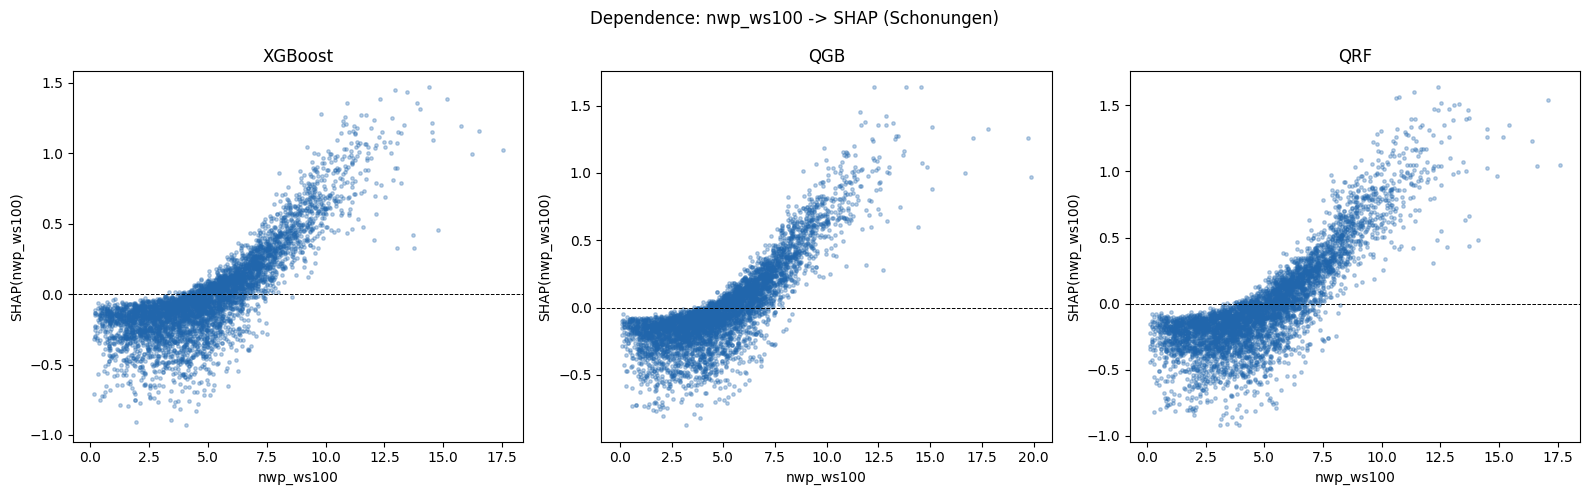

In [5]:
TOPF = "nwp_ws100" if "nwp_ws100" in FEATURES else FEATURES[int(np.argmax(np.abs(shap_data[(PLOT_PLANT,"qgb")]["shap_values"]).mean(0)))]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, mdl in zip(axes, ["xgb", "qgb", "qrf"]):
    d = shap_data[(PLOT_PLANT, mdl)]
    X = np.asarray(d["X"]); j = FEATURES.index(TOPF)
    ax.scatter(X[:, j], d["shap_values"][:, j], s=6, alpha=0.3, color="#2166ac")
    ax.axhline(0, color="k", lw=0.7, ls="--")
    ax.set_xlabel(TOPF); ax.set_ylabel(f"SHAP({TOPF})"); ax.set_title(MODELS[mdl])
plt.suptitle(f"Dependence: {TOPF} -> SHAP ({PLOT_PLANT})"); plt.tight_layout()
plt.savefig(FIGURES_DIR / f"shap_dependence_{TOPF}_{PLOT_PLANT.lower()}.png", dpi=150); plt.show()

## 5. Waterfall Plot: einzelne Vorhersage (QGB, Schonungen)

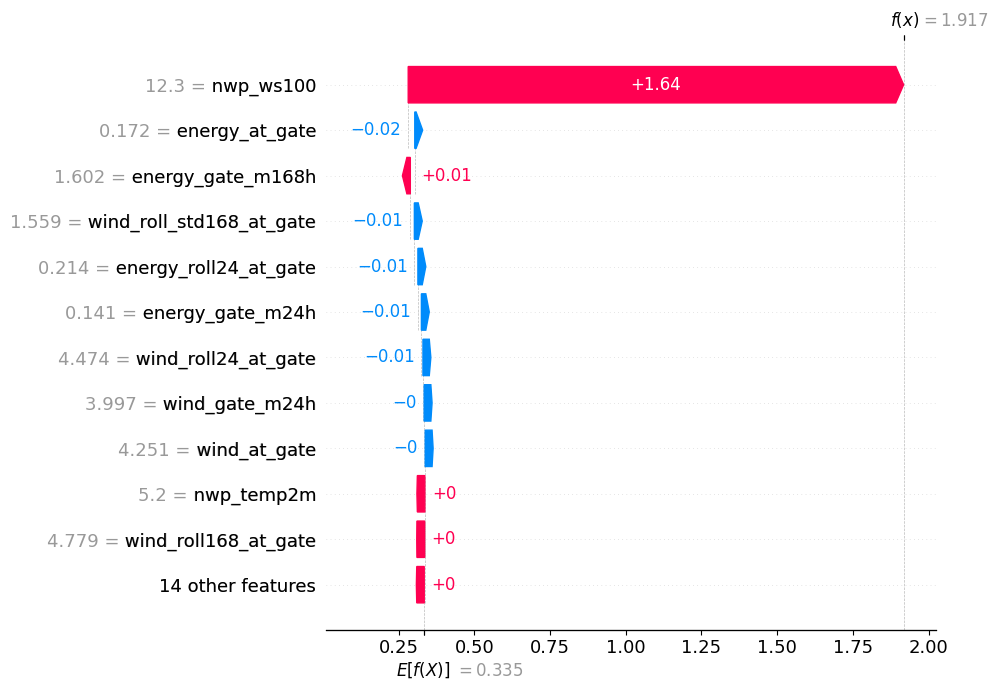

  waterfall OK (sample 4563, pred~1.917 MWh)


In [6]:
d = shap_data[(PLOT_PLANT, "qgb")]
sv = d["shap_values"]; X = np.asarray(d["X"]); base = float(d["base_value"])
i = int(np.argmax(np.abs(sv).sum(axis=1)))   # Sample mit staerkster Erklaerung
try:
    expl = shap.Explanation(values=sv[i], base_values=base, data=X[i], feature_names=FEATURES)
    shap.plots.waterfall(expl, max_display=12, show=False)
    fig = plt.gcf(); fig.set_size_inches(10, 7); plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"shap_waterfall_qgb_{PLOT_PLANT.lower()}.png", dpi=150)
    plt.show(); plt.close()
    print(f"  waterfall OK (sample {i}, pred~{base + sv[i].sum():.3f} MWh)")
except Exception as e:
    print("  waterfall FAILED:", e)

## 6. Force Plot: dieselbe Vorhersage (lokal)

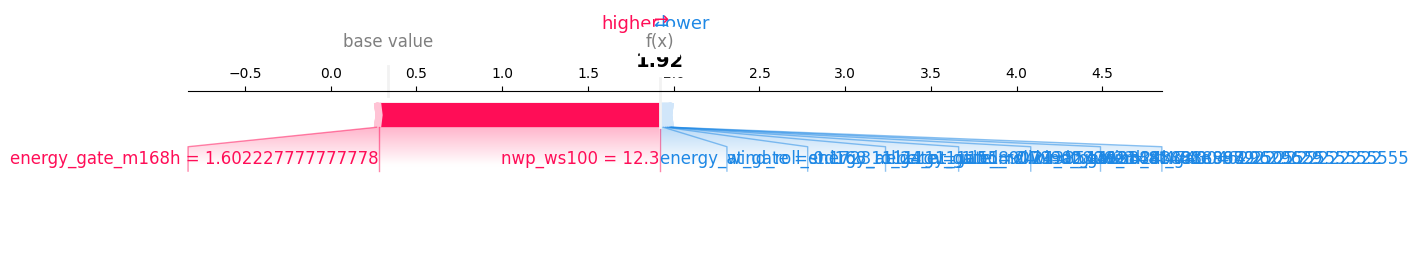

  force OK


In [7]:
try:
    shap.plots.force(base, sv[i], X[i], feature_names=FEATURES, matplotlib=True, show=False)
    fig = plt.gcf(); fig.set_size_inches(14, 3); plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"shap_force_qgb_{PLOT_PLANT.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    print("  force OK")
except Exception as e:
    print("  force FAILED:", e)

## 7. Modellvergleich: MAE / RMSE / Pinball (Grouped Bar)

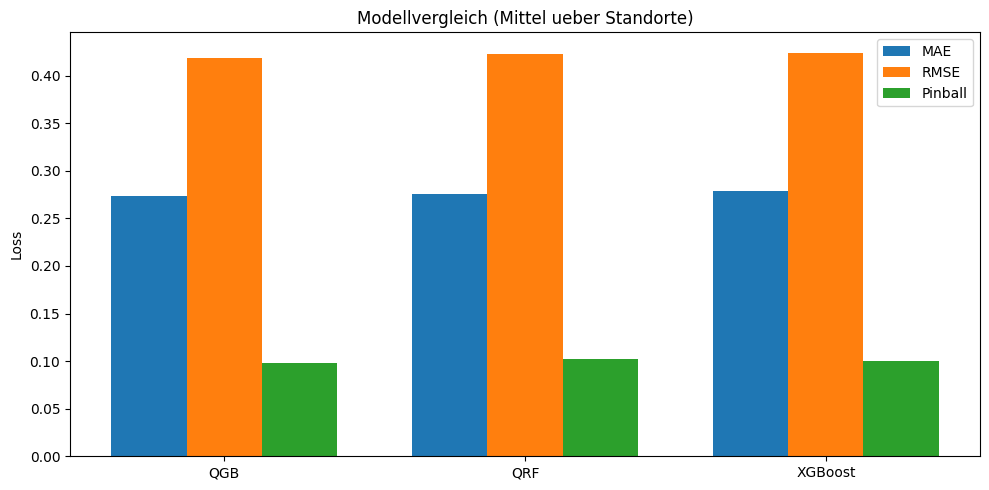

  model    MAE   RMSE  Pinball
    QGB 0.2732 0.4183   0.0985
    QRF 0.2757 0.4222   0.1023
XGBoost 0.2787 0.4242   0.1002


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
def pinball(y, yp, q): e = y - yp; return float(np.mean(np.maximum(q*e, (q-1)*e)))
QUANTILES = [0.1, 0.25, 0.5, 0.75, 0.9]

comp = []
for p in PLANTS:
    fp = FORECAST_DIR / f"predictions_{p.lower()}.csv"
    if not fp.exists(): continue
    dfp = pd.read_csv(fp)
    y = dfp["y_true"].values
    for mdl in ["xgb", "qgb", "qrf"]:
        q50 = dfp[f"{mdl}_q50"].values
        pb = np.mean([pinball(y, dfp[f"{mdl}_q{int(q*100):02d}"].values, q) for q in QUANTILES])
        comp.append({"model": MODELS[mdl],
                     "MAE": mean_absolute_error(y, q50),
                     "RMSE": np.sqrt(mean_squared_error(y, q50)),
                     "Pinball": pb})
comp_df = pd.DataFrame(comp).groupby("model").mean().reset_index()
comp_df.to_csv(TABLES_DIR / "model_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comp_df)); w = 0.25
for i, metric in enumerate(["MAE", "RMSE", "Pinball"]):
    ax.bar(x + (i-1)*w, comp_df[metric], w, label=metric)
ax.set_xticks(x); ax.set_xticklabels(comp_df["model"]); ax.set_ylabel("Loss")
ax.set_title("Modellvergleich (Mittel ueber Standorte)"); ax.legend()
plt.tight_layout(); plt.savefig(FIGURES_DIR / "model_comparison_bars.png", dpi=150); plt.show()
print(comp_df.round(4).to_string(index=False))

## 8. Pinball Loss ueber Quantile (Line, mehrere Modelle)

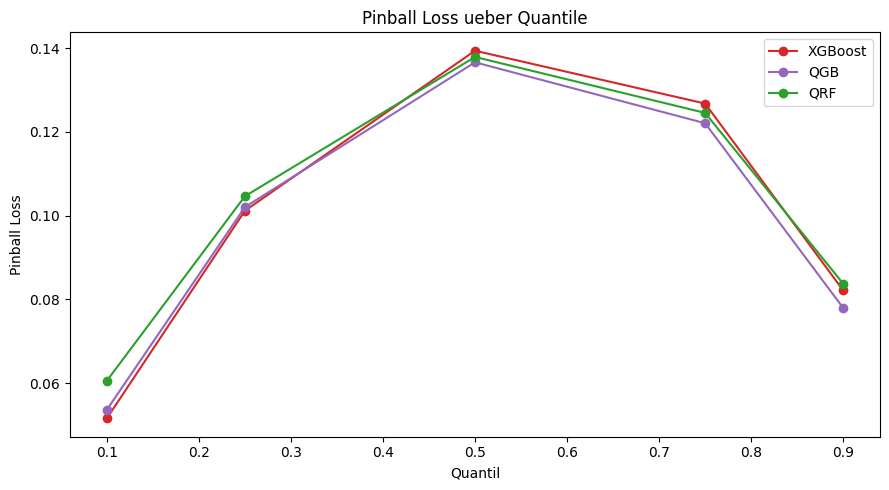

In [9]:
pb_path = TABLES_DIR / "pinball_evaluation.csv"
if pb_path.exists():
    pbdf = pd.read_csv(pb_path)
    agg = pbdf.groupby(["model", "quantile"])["pinball_loss"].mean().reset_index()
    fig, ax = plt.subplots(figsize=(9, 5))
    for mdl, c in [("xgb", "#d62728"), ("qgb", "#9467bd"), ("qrf", "#2ca02c")]:
        s = agg[agg["model"] == mdl].sort_values("quantile")
        if len(s): ax.plot(s["quantile"], s["pinball_loss"], marker="o", label=MODELS.get(mdl, mdl), color=c)
    ax.set_xlabel("Quantil"); ax.set_ylabel("Pinball Loss"); ax.set_title("Pinball Loss ueber Quantile")
    ax.legend(); plt.tight_layout()
    plt.savefig(FIGURES_DIR / "pinball_over_quantiles.png", dpi=150); plt.show()
else:
    print("pinball_evaluation.csv fehlt")

## 9. SHAP-Heatmap: Stunde x Monat (Saisonalitaet, nwp_ws100 / QGB)

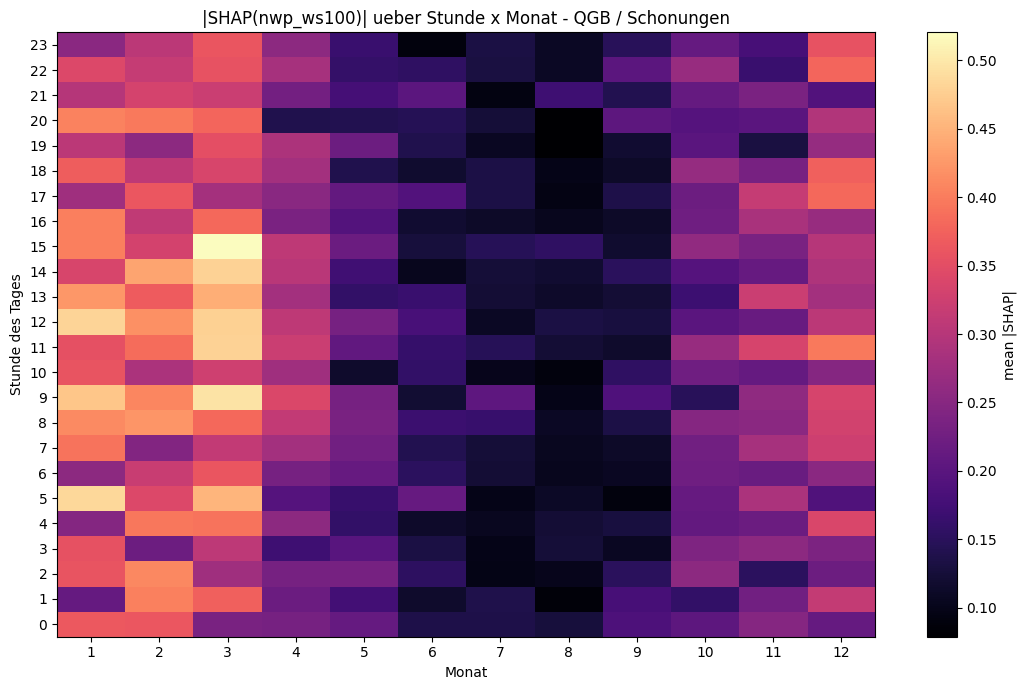

In [10]:
d = shap_data[(PLOT_PLANT, "qgb")]
ts = pd.to_datetime(d["timestamps"])
j = FEATURES.index(TOPF)
hm = pd.DataFrame({"hour": ts.hour, "month": ts.month, "abs_shap": np.abs(d["shap_values"][:, j])})
grid = hm.groupby(["hour", "month"])["abs_shap"].mean().unstack("month")
fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(grid.values, aspect="auto", cmap="magma", origin="lower")
ax.set_xticks(range(grid.shape[1])); ax.set_xticklabels(grid.columns)
ax.set_yticks(range(grid.shape[0])); ax.set_yticklabels(grid.index)
ax.set_xlabel("Monat"); ax.set_ylabel("Stunde des Tages")
ax.set_title(f"|SHAP({TOPF})| ueber Stunde x Monat - {MODELS['qgb']} / {PLOT_PLANT}")
plt.colorbar(im, ax=ax, label="mean |SHAP|"); plt.tight_layout()
plt.savefig(FIGURES_DIR / f"shap_heatmap_hour_month_{PLOT_PLANT.lower()}.png", dpi=150); plt.show()

## 10. Forecast vs Actual + Quantil-Baender (Beispielmonat)

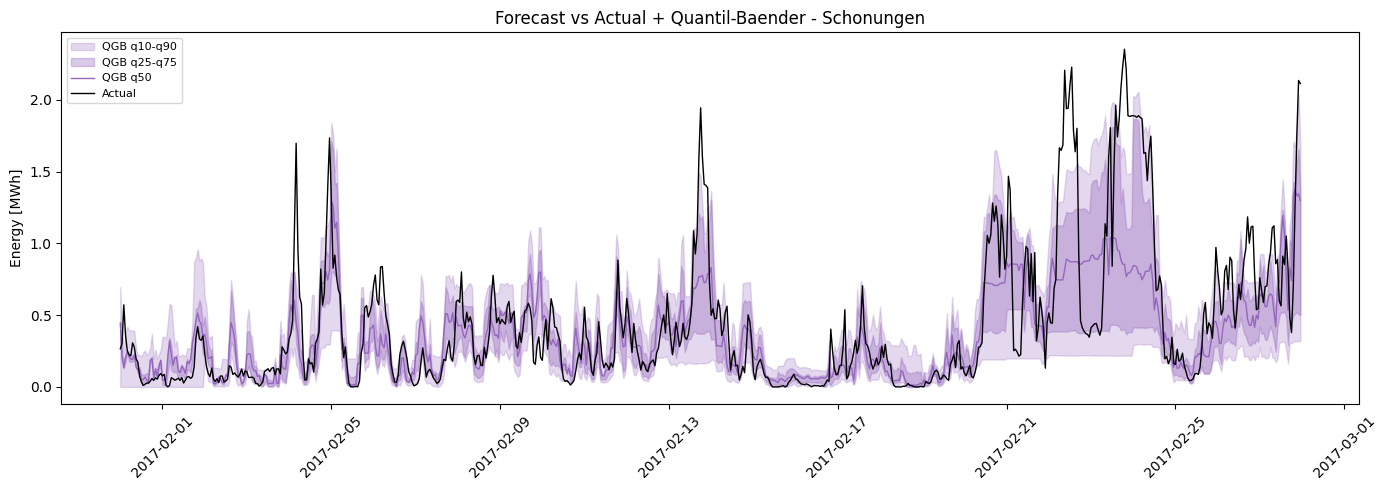

In [11]:
dfp = pd.read_csv(FORECAST_DIR / f"predictions_{PLOT_PLANT.lower()}.csv", parse_dates=["timestamp"])
m = dfp.sort_values("timestamp").iloc[:28*24]
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(m["timestamp"], m["qgb_q10"], m["qgb_q90"], alpha=0.25, color="#9467bd", label="QGB q10-q90")
ax.fill_between(m["timestamp"], m["qgb_q25"], m["qgb_q75"], alpha=0.35, color="#9467bd", label="QGB q25-q75")
ax.plot(m["timestamp"], m["qgb_q50"], color="#9467bd", lw=1.0, label="QGB q50")
ax.plot(m["timestamp"], m["y_true"], color="black", lw=1.0, label="Actual")
ax.set_title(f"Forecast vs Actual + Quantil-Baender - {PLOT_PLANT}")
ax.set_ylabel("Energy [MWh]"); ax.legend(fontsize=8); plt.xticks(rotation=45); plt.tight_layout()
plt.savefig(FIGURES_DIR / f"forecast_bands_{PLOT_PLANT.lower()}.png", dpi=150); plt.show()

## 11. Zusammenfassung

In [12]:
print("=== xAI Summary ===")
print(f"SHAP files: {len(shap_data)} (3 Modelle x 4 Standorte), je <= 5000 Samples mit X+base+timestamps")
print("Top-5 Features global:")
for f, v in imp_df.groupby("feature")["importance"].mean().nlargest(5).items():
    print(f"  {f:<28} {v:.4f}")
print()
print("Figures: shap_bar_importance, shap_beeswarm_*, shap_dependence_*, shap_waterfall_*,")
print("         shap_force_*, model_comparison_bars, pinball_over_quantiles,")
print("         shap_heatmap_hour_month_*, forecast_bands_*")

=== xAI Summary ===
SHAP files: 12 (3 Modelle x 4 Standorte), je <= 5000 Samples mit X+base+timestamps
Top-5 Features global:
  nwp_ws100                    0.3795
  nwp_wd100                    0.0291
  nwp_temp2m                   0.0227
  hour_sin                     0.0129
  hour_cos                     0.0120

Figures: shap_bar_importance, shap_beeswarm_*, shap_dependence_*, shap_waterfall_*,
         shap_force_*, model_comparison_bars, pinball_over_quantiles,
         shap_heatmap_hour_month_*, forecast_bands_*
